In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv(
    "../data/processed/superstore_clean.csv",
    parse_dates=["Order Date","Ship Date"]
)

In [2]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

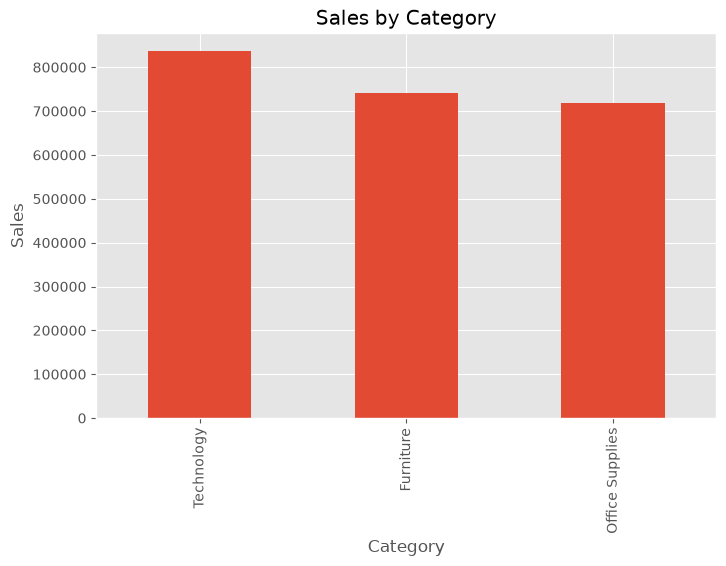

In [4]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.ylabel("Sales")

plt.title("Sales by Category")

plt.show()

### 考察

Technologyカテゴリが最も高い売上を記録している。

売上拡大を目的とする場合、
Technologyカテゴリへの投資効果が高い可能性がある。

In [5]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

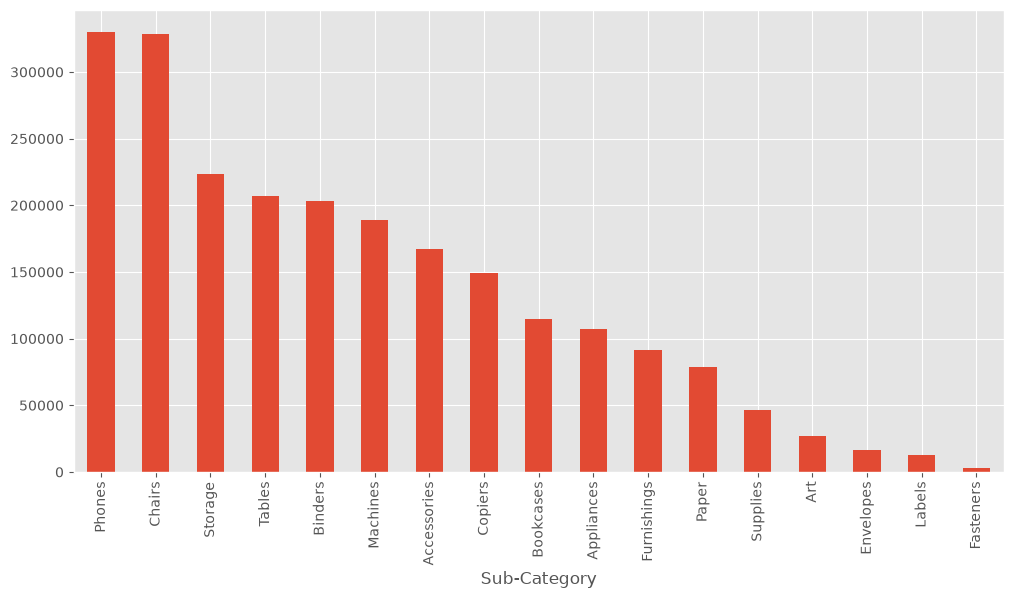

In [6]:
plt.figure(figsize=(12,6))

subcategory_sales.plot(kind="bar")

plt.show()

In [7]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
)

<Axes: xlabel='Region'>

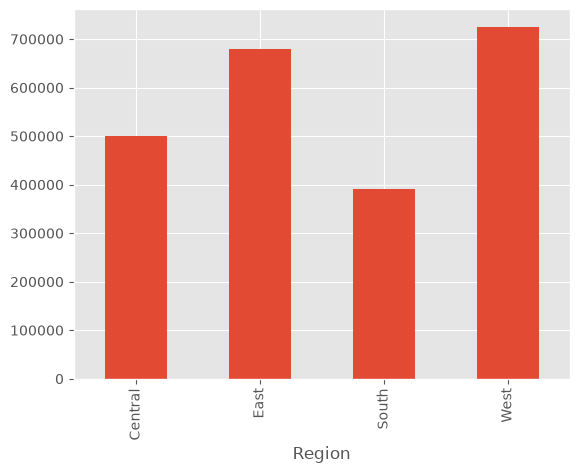

In [8]:
region_sales.plot(kind="bar")

West地域が最も売上が高い。

地域特性を考慮した販売戦略が重要である。

In [9]:
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

In [10]:
state_sales.head(10) 

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

<Axes: xlabel='State'>

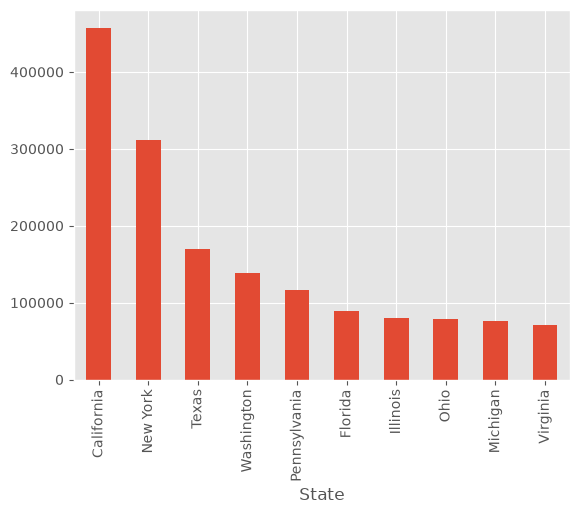

In [11]:
state_sales.head(10).plot(kind="bar")

In [12]:
product_sales = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

In [13]:
product_sales.head(10) 

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

<Axes: ylabel='Product Name'>

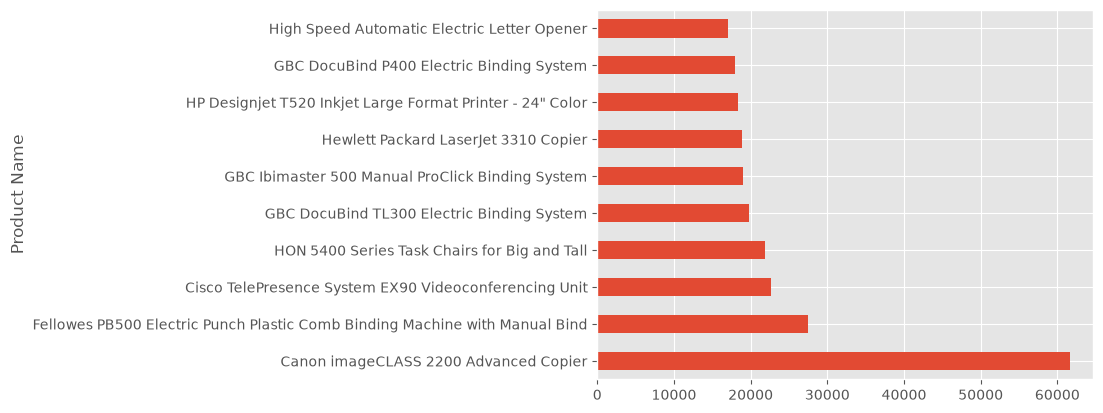

In [14]:
product_sales.head(10).plot(kind="barh")

In [15]:
customer_sales = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

In [16]:
customer_sales.head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [17]:
monthly_sales = (
    df.set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
)

<Axes: xlabel='Order Date'>

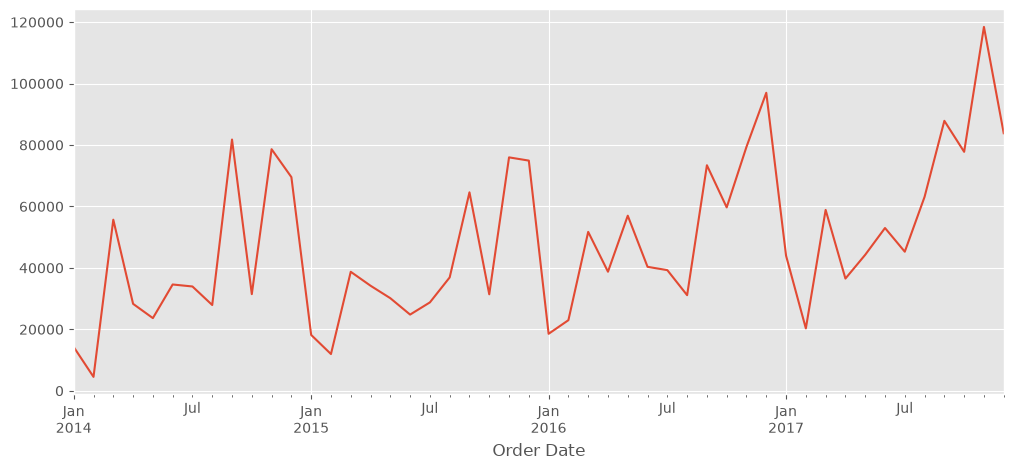

In [18]:
monthly_sales.plot(figsize=(12,5)) 

In [19]:
category_sales.to_frame() 

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


In [20]:
category_sales.reset_index() 

,Category,Sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


In [22]:
category_summary = (
    df.groupby("Category")
      .agg(
          total_sales=("Sales", "sum"),
          average_sales=("Sales", "mean"),
          order_count=("Order ID", "count")
      )
      .sort_values("total_sales", ascending=False)
)

category_summary

,total_sales,average_sales,order_count
Category,,,
Technology,836154.0330,452.709276,1847
Furniture,741999.7953,349.834887,2121
Office Supplies,719047.0320,119.324101,6026


# 売上分析まとめ

今回の分析では以下が分かった。

・Technologyカテゴリが最も売上が高い

・Phonesが売上を大きく支えている

・West地域が最も売上が高い

・上位顧客への依存度が高い可能性がある

・売上には季節性が存在する

## 売上向上施策

① Technologyカテゴリへの広告投資

② Phones商品の販促強化

③ West地域への在庫強化

④ 上位顧客向けキャンペーン

⑤ 年末需要を見越した在庫計画